<a href="https://colab.research.google.com/github/arinjay-singh/econ3916-statistical-machine-learning/blob/main/Assignment%202%20/%20econ3916_assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: The Robustness Audit (Topic 4)

## Step 1.1: The "Latency" Trap

In [1]:
# manual DGP Simulation
import numpy as np
normal_traffic = np.random.randint(20, 50, 980)
spike_traffic = np.random.randint(1000, 5000, 20)
latency_logs = np.concatenate([normal_traffic, spike_traffic])

## Step 1.2: Manual MAD vs. SD

In [2]:
def calculate_mad(data):
    '''
    1. Calculate the Median of the data
    2. Calculate Absolute Deviations (|x - median|)
    3. Return the Median of those deviations
    '''

    median = np.median(data)
    deviations = np.abs(data - median)
    mad = np.median(deviations)
    return mad

In [4]:
# Analysis: Compare the Standard Deviation (SD) vs. MAD. Explain why the SD is "exploded" by the 20 outliers while the MAD remains stable.

# std
latency_std = np.std(latency_logs)
print(f'Standard Deviation: {latency_std}')

# mad
latency_mad = calculate_mad(latency_logs)
print(f'Median Absolute Deviation: {latency_mad}')

Standard Deviation: 397.43536804743485
Median Absolute Deviation: 8.0


### Analysis

Standard Deviation squares the deviation from the mean. Therefore, the 20 outliers are significantly far from the mean, and squaring those deviations amplifies those values even more. Furthermore, the mean itself gets pulled up by the outliers, distorting the deviation calculation for every data point.

On the other hand, MAD uses the median and absolute deviation instead. Given the number of outliers, the meidan will stay firm around 35 regardless of how extreme the 20 outliers are. As a result, the absolute deviations for the 980 normal traffic data points remain small and the median of those deviations ignores the 20 large deviations caused by the outliers since they are far from the 50th percentile.

# Phase 2: The Probability Audit (Topic 5)

## Step 2.1: The False Positive Paradox

In [5]:
def bayesian_audit(prior, sensitivity, specificity):
  # probability of flagging given cheater
  p_flagged_given_cheater = sensitivity

  # probability of flagging given innocent
  p_flagged_given_innocent = 1 - specificity

  # probablity of innocent
  p_innocent = 1 - prior

  # probability of flagged as weighted average
  p_flagged = (p_flagged_given_cheater * prior) + (p_flagged_given_innocent * p_innocent)

  # posterior probability: probability of cheater given that they are flagged
  posterior = (p_flagged_given_cheater * prior) / p_flagged

  return posterior

In [15]:
# test scenarios

print('Probability of a student being a cheater given that they are flagged:')

# Scenario A (Bootcamp): Base Rate = 50%
post_prob_a = bayesian_audit(0.5, 0.98, 0.98)
print(f'Bootcamp (base rate = 50%): {post_prob_a:.2f}')

# Scenario B (Econ Class): Base Rate = 5%
post_prob_b = bayesian_audit(0.05, 0.98, 0.98)
print(f'Econ Class (base rate = 5%): {post_prob_b:.2f}')

# Scenario C (Honors Seminar): Base Rate = 0.1%
post_prob_c = bayesian_audit(0.001, 0.98, 0.98)
print(f'Honors Seminar (base rate = 0.1%): {post_prob_c:.2f}')


Probability of a student being a cheater given that they are flagged:
Bootcamp (base rate = 50%): 0.98
Econ Class (base rate = 5%): 0.72
Honors Seminar (base rate = 0.1%): 0.05


# Phase 3: The Bias Audit (Topic 6)

## Step 3.1: Detecting Sample Ratio Mismatch (SRM)

In [18]:
# expected: 50/50 split of 100,000
observed = np.array([50250, 49750])
expected = np.array([50000, 50000])

# Chi-Square Formula: Sum( (Observed - Expected)^2 / Expected )
chi_square = np.sum((observed - expected) ** 2 / expected)

# critical value for (p < 0.05)
critical_value = 3.84

print(f"Observed: {observed}")
print(f"Expected: {expected}")
print(f"Chi-Square Statistic: {chi_square}")
print(f"Critical Value (α=0.05): {critical_value}")
print(f"Result: {'INVALID due to engineering bias' if chi_square > critical_value else 'Valid split'}")

Observed: [50250 49750]
Expected: [50000 50000]
Chi-Square Statistic: 2.5
Critical Value (α=0.05): 3.84
Result: Valid split


# Phase 4: AI Expansion (The Co-Pilot Era)

## Task 4.1: The "Memecoin Graveyard" Simulation

=== Survivorship Bias Audit ===
Total Tokens Launched: 10,000
Survivors (Top 1%):    100
Dead Tokens (99%):     9,900

Mean Market Cap (All):       $7,960.54
Mean Market Cap (Survivors): $359,555.75
Median Market Cap (All):     $1,970.55

Survivor mean is 45.2x the true mean


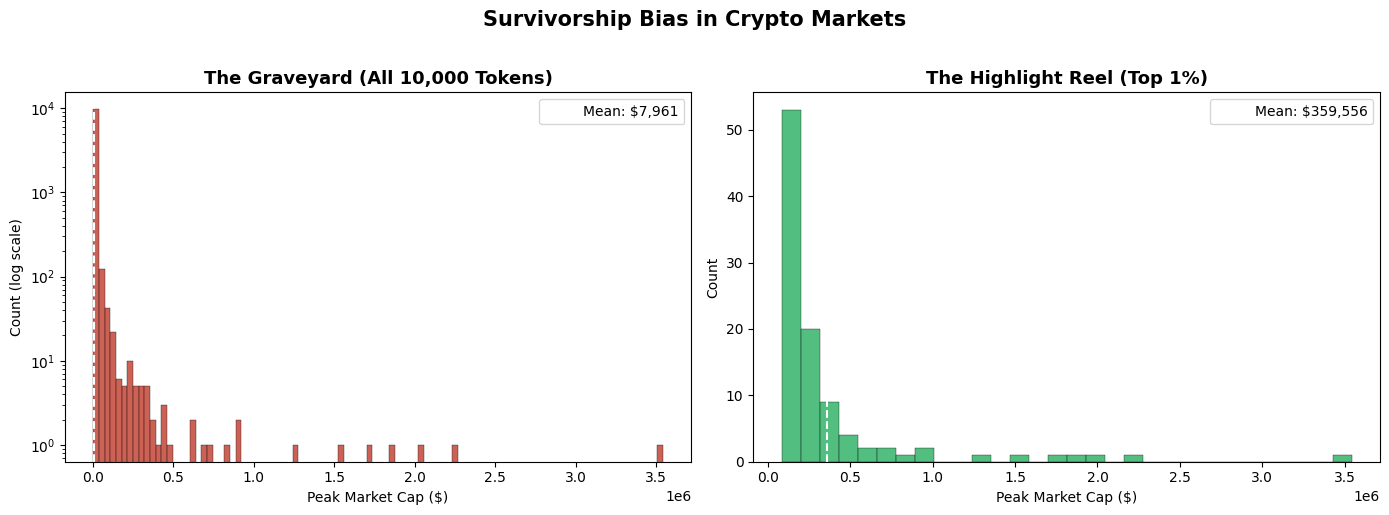

In [19]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_tokens = 10000
peak_market_caps = (np.random.pareto(a=1, size=n_tokens) + 1) * 1000

df_all = peak_market_caps

threshold = np.percentile(peak_market_caps, 99)
df_survivors = peak_market_caps[peak_market_caps >= threshold]

print("=== Survivorship Bias Audit ===")
print(f"Total Tokens Launched: {n_tokens:,}")
print(f"Survivors (Top 1%):    {len(df_survivors)}")
print(f"Dead Tokens (99%):     {n_tokens - len(df_survivors):,}")
print(f"\nMean Market Cap (All):       ${np.mean(df_all):,.2f}")
print(f"Mean Market Cap (Survivors): ${np.mean(df_survivors):,.2f}")
print(f"Median Market Cap (All):     ${np.median(df_all):,.2f}")
print(f"\nSurvivor mean is {np.mean(df_survivors)/np.mean(df_all):.1f}x the true mean")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_all, bins=100, color='#c0392b', alpha=0.8, edgecolor='black', linewidth=0.3)
axes[0].set_yscale('log')
axes[0].set_title('The Graveyard (All 10,000 Tokens)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Peak Market Cap ($)')
axes[0].set_ylabel('Count (log scale)')
axes[0].axvline(np.mean(df_all), color='white', linestyle='--', linewidth=1.5, label=f'Mean: ${np.mean(df_all):,.0f}')
axes[0].legend()

axes[1].hist(df_survivors, bins=30, color='#27ae60', alpha=0.8, edgecolor='black', linewidth=0.3)
axes[1].set_title('The Highlight Reel (Top 1%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Peak Market Cap ($)')
axes[1].set_ylabel('Count')
axes[1].axvline(np.mean(df_survivors), color='white', linestyle='--', linewidth=1.5, label=f'Mean: ${np.mean(df_survivors):,.0f}')
axes[1].legend()

plt.suptitle('Survivorship Bias in Crypto Markets', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()